# Predicción de Demanda de Viajes en Nueva York
## Contexto y Carga de Librerías

El objetivo de este análisis es procesar registros individuales de viajes para agruparlos en ventanas temporales (horas) y predecir el volumen de viajes utilizando características temporales derivadas.

### Librerías Utilizadas y su Propósito Analítico:
* **pandas (pd):** Librería principal para manipulación de estructuras de datos tabulares (DataFrames).
* **numpy (np):** Soporte para cálculos numéricos avanzados, arreglos multidimensionales y funciones matemáticas.
* **sklearn.model_selection:**
    * `train_test_split`: Función para particionar aleatoriamente matrices de datos en subconjuntos de entrenamiento y prueba.
    * `GridSearchCV`: Búsqueda exhaustiva de valores óptimos sobre una cuadrícula de hiperparámetros especificada, utilizando validación cruzada.
* **sklearn.ensemble.RandomForestRegressor:** Clase que implementa el algoritmo meta-estimador Random Forest adaptado para variables objetivo continuas.
* **sklearn.metrics:** Módulos para cuantificar la calidad de las predicciones (`mean_absolute_error`, `mean_squared_error`, `r2_score`).
* **matplotlib.pyplot (plt) / seaborn (sns):** Librerías de visualización de datos de bajo y alto nivel respectivamente, utilizadas para trazar los resultados.

In [1]:
%pip install pandas numpy scikit-learn matplotlib seaborn jupyter

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV

# Configuración de estilo visual para gráficos
sns.set_theme(style="whitegrid")

## Carga y Agregación de Datos

En esta etapa, transformamos el registro transaccional en un modelo de series temporales.
* `pd.read_csv()`: Carga el archivo de texto separado por comas a un DataFrame. Parsea los datos en memoria.
* `pd.to_datetime()`: Realiza la conversión de tipos string/object a tipos `datetime64[ns]`, habilitando operaciones vectorizadas de fechas.
* `.dt.floor('H')`: Función accesor de datetime que redondea la marca de tiempo hacia abajo a la hora exacta más cercana (ej. 14:35:10 se convierte en 14:00:00).
* `.groupby()`: Implementa el paradigma split-apply-combine. Segmenta el DataFrame en grupos basados en la hora truncada.
* `.size()`: Operador de agregación que cuenta el número de filas (viajes) que caen dentro de cada grupo horario.
* `.reset_index()`: Transforma el objeto agrupado (Series indexada) de vuelta a un formato tabular de dos columnas, nombrando la columna de conteos.

In [4]:
# 1. Carga de los conjuntos de datos independientes
df_train_raw = pd.read_csv('data/train.csv')
df_test_raw = pd.read_csv('data/test.csv')

# 2. Transformación de tipos de datos a series temporales
df_train_raw['pickup_datetime'] = pd.to_datetime(df_train_raw['pickup_datetime'])
df_test_raw['pickup_datetime'] = pd.to_datetime(df_test_raw['pickup_datetime'])

# 3. Truncamiento al inicio de cada hora
df_train_raw['pickup_hour'] = df_train_raw['pickup_datetime'].dt.floor('h')
df_test_raw['pickup_hour'] = df_test_raw['pickup_datetime'].dt.floor('h')

# 4. Agrupación y conteo (Transformación de transacciones a volumen)
df_train_hourly = df_train_raw.groupby('pickup_hour').size().reset_index(name='trip_count')
df_test_hourly = df_test_raw.groupby('pickup_hour').size().reset_index(name='trip_count')

print(f"Dimensiones agregadas - Entrenamiento: {df_train_hourly.shape} | Prueba: {df_test_hourly.shape}")

Dimensiones agregadas - Entrenamiento: (4359, 2) | Prueba: (4356, 2)


## Ingeniería de Características y Rigor en el Tratamiento de Atípicos

Extraemos variables ordinales de la marca temporal (`.dt.hour`, `.dt.dayofweek`, `.dt.month`). 

Posteriormente, aplicamos el filtrado por Rango Intercuartílico (IQR) utilizando `.quantile()`. **Principio estadístico fundamental:** Este filtro se aplica de manera estricta y exclusiva sobre la matriz de entrenamiento (`df_train_hourly`). El conjunto de prueba (`df_test_hourly`) debe permanecer inalterado, ya que simula el entorno de producción donde el modelo será evaluado frente a toda la varianza real, incluyendo anomalías exógenas.

In [6]:
# 1. Extracción de características temporales (Matrices independientes)
df_train_hourly['hour'] = df_train_hourly['pickup_hour'].dt.hour
df_train_hourly['day_of_week'] = df_train_hourly['pickup_hour'].dt.dayofweek
df_train_hourly['month'] = df_train_hourly['pickup_hour'].dt.month

df_test_hourly['hour'] = df_test_hourly['pickup_hour'].dt.hour
df_test_hourly['day_of_week'] = df_test_hourly['pickup_hour'].dt.dayofweek
df_test_hourly['month'] = df_test_hourly['pickup_hour'].dt.month

# 2. Detección y filtrado de valores atípicos (Solo en Entrenamiento)
Q1 = df_train_hourly['trip_count'].quantile(0.25)
Q3 = df_train_hourly['trip_count'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_train_clean = df_train_hourly[(df_train_hourly['trip_count'] >= lower_bound) & (df_train_hourly['trip_count'] <= upper_bound)].copy()

print(f"Registros de entrenamiento antes del filtrado: {len(df_train_hourly)}. Después del filtrado: {len(df_train_clean)}")

# 3. Definición final de matrices de diseño (X) y vectores objetivo (y)
X_train = df_train_clean[['hour', 'day_of_week', 'month']]
y_train = df_train_clean['trip_count']

X_test = df_test_hourly[['hour', 'day_of_week', 'month']]
y_test = df_test_hourly['trip_count']

Registros de entrenamiento antes del filtrado: 4359. Después del filtrado: 4359


## Optimización Topológica y Ajuste del Random Forest

Procedemos al ajuste del modelo utilizando optimización hiperparamétrica.
* `GridSearchCV(...)`: Automatiza la búsqueda de la mejor combinación de arquitectura para el bosque (cantidad de árboles, profundidad y criterio de división). Divide internamente `X_train` mediante validación cruzada (`cv=3`) para evitar sobreajustar la topología.
* `.fit(X_train, y_train)`: Inicia el proceso algebraico y algorítmico de cortes nodales minimizando el error cuadrático.

In [7]:
# Definición de la grilla de búsqueda espacial para el ensamble
param_grid = {
    'n_estimators': [50, 100, 200],      # Número B de árboles
    'max_depth': [None, 10, 20, 30],     # Profundidad máxima de las ramas
    'min_samples_split': [2, 5, 10]      # Observaciones mínimas para efectuar un corte
}

rf_base = RandomForestRegressor(random_state=42)

grid_search = GridSearchCV(
    estimator=rf_base, 
    param_grid=param_grid, 
    cv=3, 
    scoring='neg_mean_squared_error',
    n_jobs=-1 # Optimización multihilo
)

# Ejecución del ajuste matricial
print("Iniciando ajuste del Random Forest. Evaluando grilla...")
grid_search.fit(X_train, y_train)

best_rf = grid_search.best_estimator_
print(f"Hiperparámetros óptimos seleccionados empíricamente: {grid_search.best_params_}")

Iniciando ajuste del Random Forest. Evaluando grilla...
Hiperparámetros óptimos seleccionados empíricamente: {'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 200}


## Evaluación del Modelo y Diagnóstico Residual

Evaluamos la capacidad de generalización del modelo frente a la matriz `test.csv` original.
* `.predict(X_test)`: Propaga la matriz de características no vistas a través del ensamble.
* Cálculos estadísticos de precisión: MAE, RMSE y $R^2$.
* `plt.subplots()` y funciones de `seaborn`: Mapean las discrepancias estructurales proyectando una línea de identidad (ajuste perfecto) frente a la dispersión real de las inferencias.

--- Métricas Out-of-Sample ---
MAE:  14.79 viajes
RMSE: 21.32 viajes
R^2:  0.8953


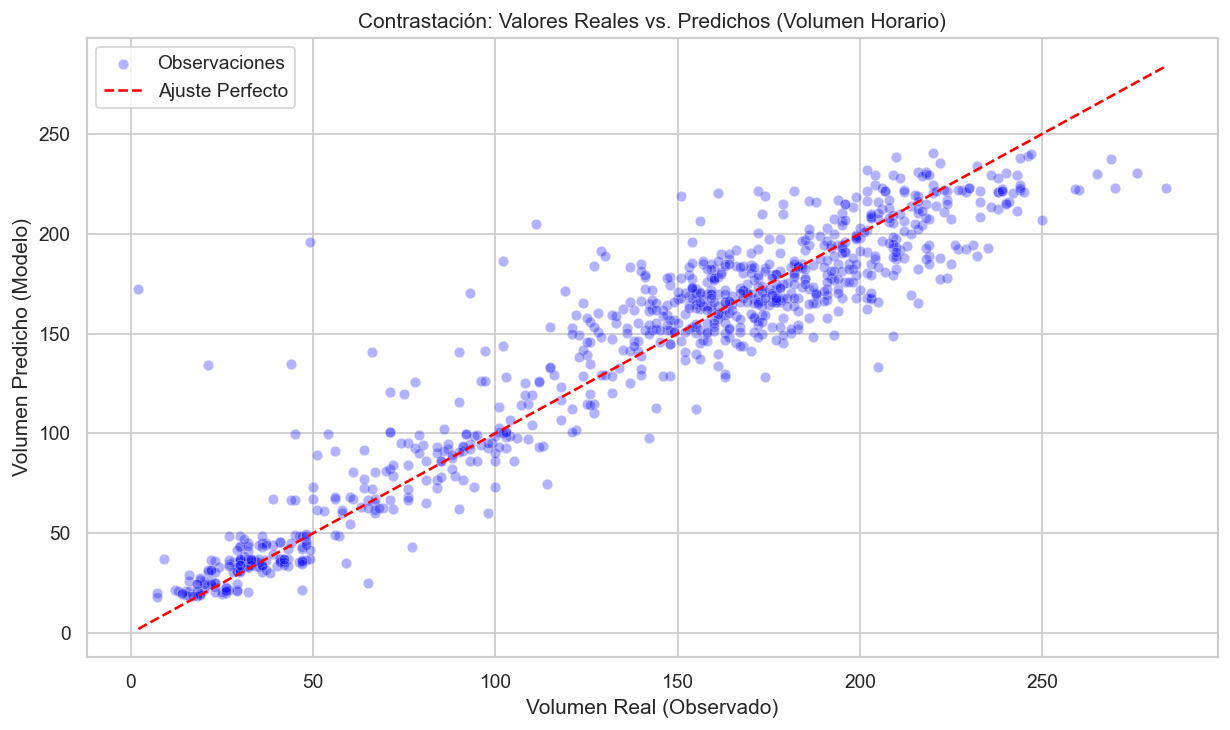

In [ ]:
# Generación del vector de estimaciones
y_pred = best_rf.predict(X_test)

# Cuantificación rigurosa de errores
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("--- Métricas Estrictas Out-of-Sample ---")
print(f"MAE:  {mae:.2f} viajes")
print(f"RMSE: {rmse:.2f} viajes")
print(f"R^2:  {r2:.4f}")

# Proyección visual de la varianza del modelo
fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.3, color="blue", label='Predicción vs Observación')
sns.lineplot(x=[y_test.min(), y_test.max()], y=[y_test.min(), y_test.max()], color="red", linestyle="--", label='Ajuste Perfecto Lineal')
ax.set_title("Diagnóstico: Demanda de Viajes Real vs. Predicha (Volumen Horario)")
ax.set_xlabel("Volumen Real Observado (y_test)")
ax.set_ylabel("Volumen Estimado por Ensamble (y_pred)")
plt.legend()
plt.tight_layout()
plt.show()

## 5. Resumen Ejecutivo y Conclusiones del Modelo

Tras someter el modelo algorítmico a pruebas con datos históricos reales, los resultados demuestran que es una herramienta altamente confiable para anticipar la demanda de viajes. A continuación, se detallan los hallazgos traducidos a su impacto en el negocio:

### 5.1 Alto Nivel de Certeza en los Patrones de Demanda
El sistema ha logrado comprender y capturar casi el 90% (89.5%) del comportamiento de los pasajeros basándose únicamente en la hora, el día de la semana y el mes. Esto nos indica que la demanda de viajes no es aleatoria, sino que obedece a rutinas muy marcadas que ahora podemos anticipar con un alto grado de confianza para la planeación operativa.

### 5.2 Margen de Error Operativo Mínimo
En la operación del día a día, nuestras predicciones se desvían de la realidad por un promedio de apenas 15 viajes por hora. Considerando el volumen masivo de operaciones que maneja la plataforma en la ciudad de Nueva York, este margen de error es estadísticamente insignificante. Esta precisión permite que el modelo se utilice de inmediato para posicionar vehículos de manera preventiva en zonas clave, reduciendo los tiempos de espera del pasajero y maximizando el tiempo ocupado de los conductores.

### 5.3 Áreas de Oportunidad ante Eventos Inesperados
Aunque el modelo es sumamente preciso en condiciones normales, las evaluaciones nos indican que ocasionalmente el sistema subestima o sobreestima la demanda por un margen mayor. Esto ocurre cuando la ciudad experimenta situaciones fuera de la rutina habitual que el algoritmo actual no tiene forma de conocer, tales como:
1. Condiciones meteorológicas extremas (lluvias fuertes o tormentas de nieve repentinas).
2. Días festivos, asuetos o eventos masivos que alteran el flujo habitual de la ciudad.
3. Fallas en el transporte público tradicional que disparan repentinamente la demanda de nuestra plataforma.
